In [1]:
import pandas as pd 


data = pd.read_csv("timeseries_hse_teducation_df.csv", delimiter=',')

In [2]:
# use darts plotting style
from darts import set_option

set_option("plotting.use_darts_style", True)

In [3]:
data.head()

,Unnamed: 0,ts_name,dttm_30,y
0,0,ts_name_0,2023-01-01 00:00:00,23
1,1,ts_name_1,2023-01-01 00:00:00,43
2,2,ts_name_2,2023-01-01 00:00:00,4
3,3,ts_name_3,2023-01-01 00:00:00,1
4,4,ts_name_4,2023-01-01 00:00:00,27


In [4]:
data.shape

(555146, 4)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555146 entries, 0 to 555145
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  555146 non-null  int64 
 1   ts_name     555146 non-null  object
 2   dttm_30     555146 non-null  object
 3   y           555146 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 16.9+ MB


In [6]:
missing_values = data.isnull().sum()
print(missing_values)

Unnamed: 0    0
ts_name       0
dttm_30       0
y             0
dtype: int64


#Выбираем данные с ts_name = ts_name_1

In [7]:
ts_name_1_data = data[data['ts_name'] == 'ts_name_1']

In [8]:
ts_name_1_data.head()

,Unnamed: 0,ts_name,dttm_30,y
1,1,ts_name_1,2023-01-01 00:00:00,43
9,9,ts_name_1,2023-01-01 00:30:00,71
17,17,ts_name_1,2023-01-01 01:00:00,74
25,25,ts_name_1,2023-01-01 01:30:00,78
33,33,ts_name_1,2023-01-01 02:00:00,59


In [9]:
from darts import TimeSeries


ts_name_1_series = TimeSeries.from_dataframe(ts_name_1_data, 'dttm_30', 'y') #Преобразуем данные из df в TimeSeries
ts_name_1_series

,y
dttm_30,
2023-01-01 00:00:00,43.0
2023-01-01 00:30:00,71.0
2023-01-01 01:00:00,74.0
2023-01-01 01:30:00,78.0
2023-01-01 02:00:00,59.0
...,...
2025-12-20 21:30:00,1107.0
2025-12-20 22:00:00,1078.0
2025-12-20 22:30:00,1094.0


<Axes: xlabel='dttm_30'>

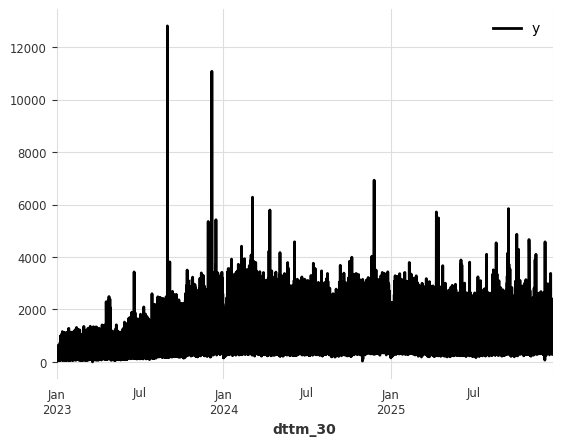

In [10]:
ts_name_1_series.plot()

<Axes: xlabel='dttm_30'>

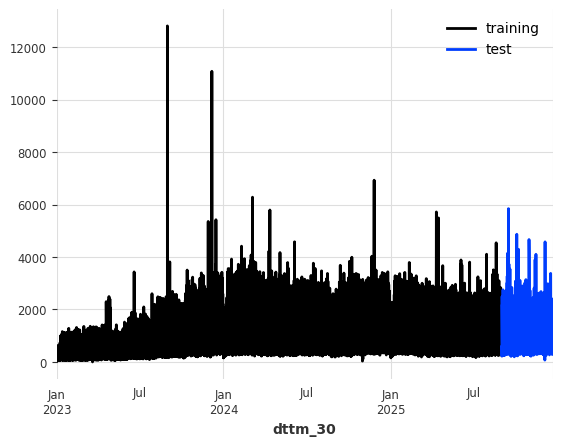

In [11]:
#Делим данные на тренировочную и тестовую выборку
ts_name_1_series_train, ts_name_1_series_test = ts_name_1_series.split_before(pd.Timestamp("2025-09-01 00:00:00"))
ts_name_1_series_train.plot(label="training")
ts_name_1_series_test.plot(label="test")

In [12]:
#Выбираем только первые 60 дней из тестовой выборки
ts_name_1_series_test_60, _ = ts_name_1_series_test.split_before(pd.Timestamp('2025-11-01 00:00:00'))

In [13]:
from darts.models import Prophet


#Обучение 
prophet_model = Prophet()
prophet_model.fit(ts_name_1_series_train)

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
18:52:38 - cmdstanpy - INFO - Chain [1] start processing
18:53:00 - cmdstanpy - INFO - Chain [1] done processing


Prophet(add_seasonalities=None, add_regressor_configs=None, country_holidays=None, cap=None, floor=None, add_encoders=None, random_state=None, suppress_stdout_stderror=True)

In [14]:
forecast_60 = prophet_model.predict(2880)

In [15]:
import matplotlib.pyplot as plt

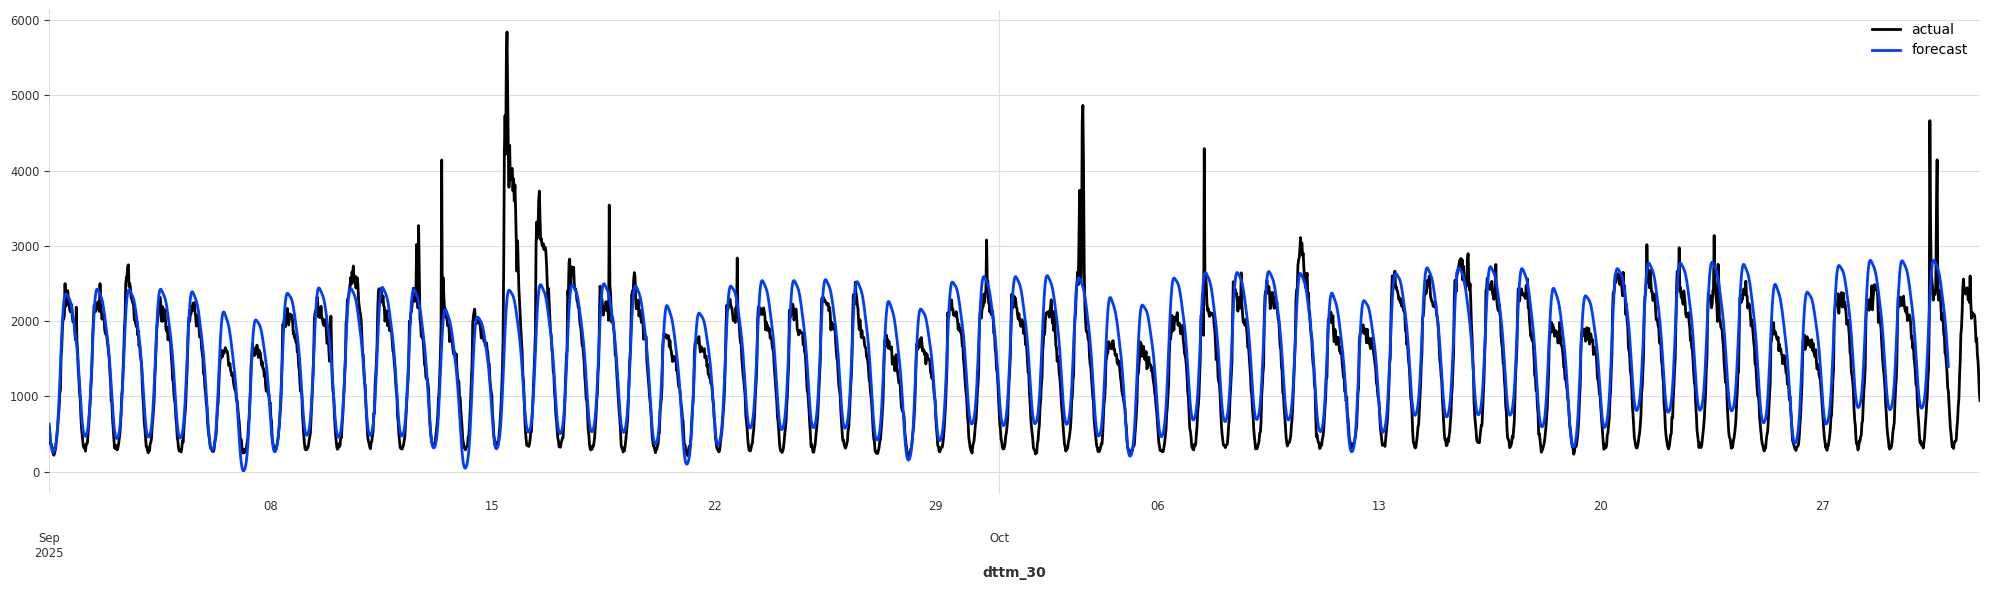

In [17]:
plt.figure(figsize=(20, 6))
ts_name_1_series_test_60.plot(label="actual")
forecast_60.plot(label="forecast")
plt.tight_layout()
plt.show()

In [18]:
from darts.metrics import mape


print(mape(ts_name_1_series_test_60, forecast_60))

27.32093537514532


In [20]:
ts_name_7_data = data[data['ts_name'] == 'ts_name_7']

In [21]:
ts_name_7_data.head()

,Unnamed: 0,ts_name,dttm_30,y
7,7,ts_name_7,2023-01-01 00:00:00,423
15,15,ts_name_7,2023-01-01 00:30:00,550
23,23,ts_name_7,2023-01-01 01:00:00,544
31,31,ts_name_7,2023-01-01 01:30:00,519
39,39,ts_name_7,2023-01-01 02:00:00,464


In [22]:
ts_name_7_series = TimeSeries.from_dataframe(ts_name_7_data, 'dttm_30', 'y') #Преобразуем данные из df в TimeSeries
ts_name_7_series

,y
dttm_30,
2023-01-01 00:00:00,423.0
2023-01-01 00:30:00,550.0
2023-01-01 01:00:00,544.0
2023-01-01 01:30:00,519.0
2023-01-01 02:00:00,464.0
...,...
2025-12-20 21:30:00,3131.0
2025-12-20 22:00:00,2855.0
2025-12-20 22:30:00,2623.0


<Axes: xlabel='dttm_30'>

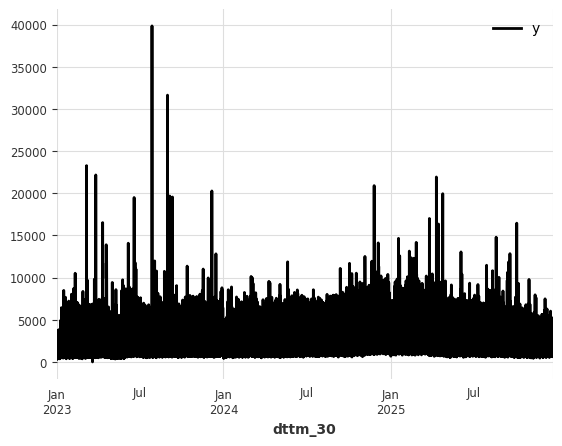

In [23]:
ts_name_7_series.plot()

<Axes: xlabel='dttm_30'>

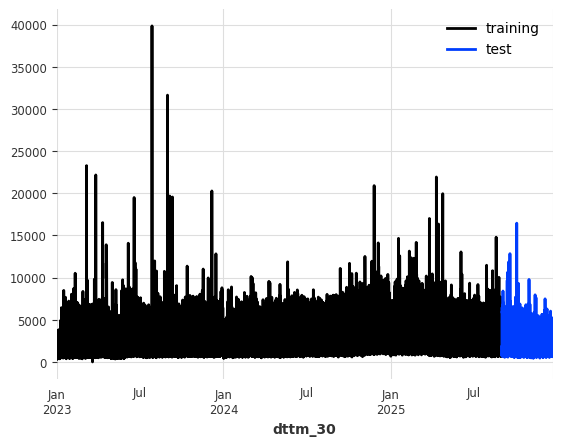

In [24]:
#Делим данные на тренировочную и тестовую выборку
ts_name_7_series_train, ts_name_7_series_test = ts_name_7_series.split_before(pd.Timestamp("2025-09-01 00:00:00"))
ts_name_7_series_train.plot(label="training")
ts_name_7_series_test.plot(label="test")

In [25]:
#Выбираем только первые 60 дней из тестовой выборки
ts_name_7_series_test_60, _ = ts_name_7_series_test.split_before(pd.Timestamp('2025-11-01 00:00:00'))

In [26]:
prophet_model = Prophet()
prophet_model.fit(ts_name_7_series_train)

18:57:46 - cmdstanpy - INFO - Chain [1] start processing
18:58:14 - cmdstanpy - INFO - Chain [1] done processing


Prophet(add_seasonalities=None, add_regressor_configs=None, country_holidays=None, cap=None, floor=None, add_encoders=None, random_state=None, suppress_stdout_stderror=True)

In [27]:
forecast_60 = prophet_model.predict(2880)

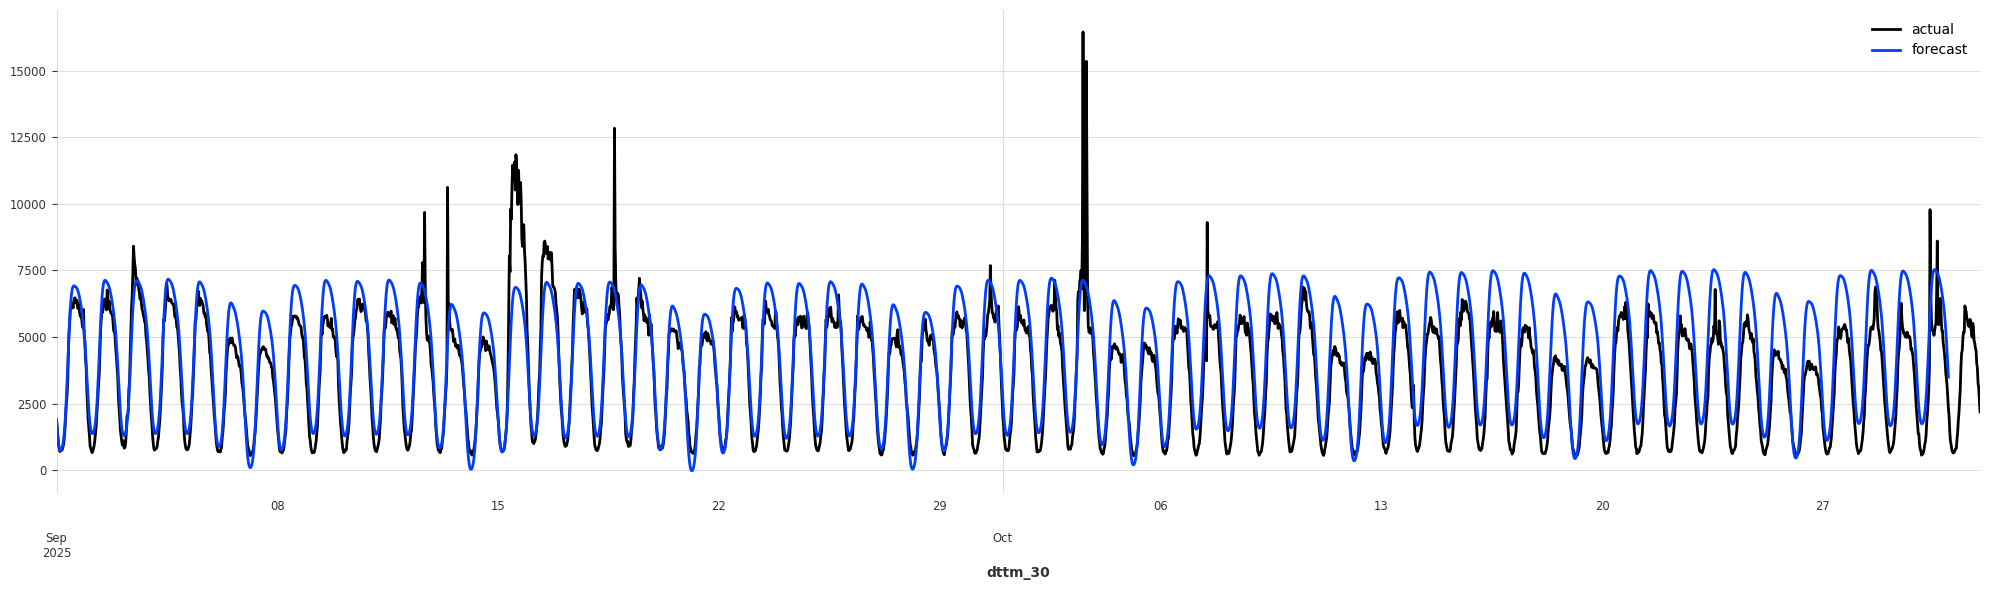

In [29]:
plt.figure(figsize=(20, 6))
ts_name_7_series_test_60.plot(label="actual")
forecast_60.plot(label="forecast")
plt.tight_layout()
plt.show()

In [30]:
print(mape(ts_name_7_series_test_60, forecast_60))

34.99615795337175
